In [22]:
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!apt-get -qq install fonts-nanum

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rc("font", family=font_name)
plt.rcParams["axes.unicode_minus"] = False

In [23]:
# 1. Seaborn은 Python의 데이터 시각화 라이브러리로, matplotlib을 기반으로 하고 있지만, 더 직관적이고 고급스러운 그래프를 그릴 수 있도록 도와주는 도구
# 2. 통계적 시각화에 특화
# 3. Seaborn은 pandas DataFrame과의 통합이 매우 잘 되어 있어서, pandas에서 직접 데이터를 처리한 뒤 Seaborn으로 바로 시각화
# 4. Seaborn은 기본적으로 아름다운 색상 팔레트와 디자인을 제공

In [24]:
# 수치형 1개
# - 히스토그램   sns.histplot() ,plt.hist() 
# - 분포도 sns.diplot()
# - 박스플롯 sns.boxplot()

# 수치형 2개 이상(변수 관계 확인)
# - 히트맵 sns.heatmap() = 변수관 상관계수 확인
# - 라인플롯 sns.linplot()
# - 산점도 sns.scatterplot()
# - 페어프롯 sns.pairplot()

# 범주형 

# 범주형 1개
# - 카운트 플롯 sns.countplot()

# 범주형 2개 이상(변수 관계 확인)
# - 막대그래프  sns.barplot()
# - 포인트플롯  sns.pointplot()
# - 박스플롯    sns.boxplot()
# - 바이올린 플롯 sns.violinplot()

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 시각화를 통한 EDA(탐색적 분석)

df_tips = sns.load_dataset("tips")

df_tips.info()

# category = 범주형 object = 스트링 문자열

#분석 = 인사이트 도출
# 1. tips 데이터는 7개의 컬럼으로 이루어져 있다.
# 2. 3개의 수치형 데이터 와 4개의 범주형 데이터
# 3. 결측치는 없으며, 244개의 행으로 이루어져 있다.

df_tips.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


In [26]:
df_tips.to_excel("tips_all.xlsx",index=False)

(array([ 0., 10., 20., 30., 40., 50., 60.]),
 [Text(0.0, 0, '0'),
  Text(10.0, 0, '10'),
  Text(20.0, 0, '20'),
  Text(30.0, 0, '30'),
  Text(40.0, 0, '40'),
  Text(50.0, 0, '50'),
  Text(60.0, 0, '60')])

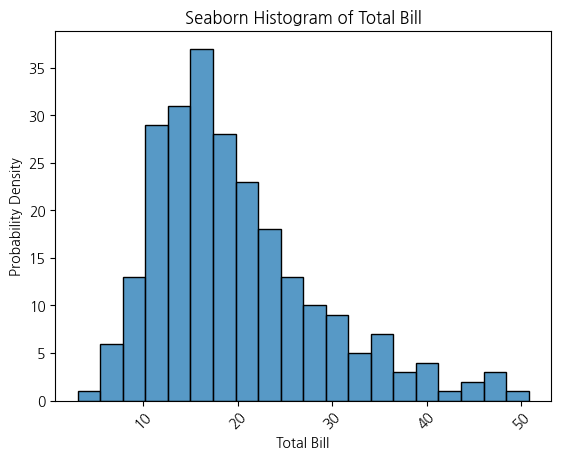

In [27]:
# 분석상 total_bill 과 tips 가 가장 중요한 컬럼으로 인식됨
# tips["total_bill"] 히스토그램을 Seaborn으로 그리기

sns.histplot(data=df_tips,x="total_bill",bins=20)

plt.xlabel("Total Bill")
plt.ylabel("Probability Density")
plt.title("Seaborn Histogram of Total Bill")
plt.xticks(rotation=45)

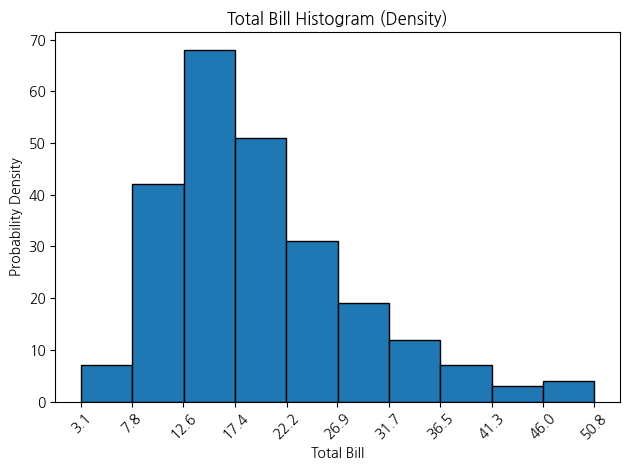

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 데이터 불러오기
tips = sns.load_dataset("tips")

# 히스토그램 정보
bins = 10
counts, bin_edges, _ = plt.hist(
    tips["total_bill"],
    bins=bins,
    density=False,  # 확률 밀도
    edgecolor='black'
)

# x축 눈금 수동 지정: bin 경계값들을 x축 눈금으로 설정
plt.xticks(np.round(bin_edges, 1), rotation=45)  # 필요하면 회전

plt.xlabel("Total Bill")
plt.ylabel("Probability Density")
plt.title("Total Bill Histogram (Density)")
plt.tight_layout()
plt.show()

In [29]:
# 수치로 확인
df_tips["total_bill"].describe()

# 분석 인사이트 도출
# total_bill 최대 50.810000 최소 3.07 평균 19.78 임을 확인 할 수 있다.
# 평균과 중위값의 차이가 2달러 정도 차이가 난다.


,total_bill
count,244.000000
mean,19.785943
std,8.902412
min,3.070000
25%,13.347500
50%,17.795000
75%,24.127500
max,50.810000


<Axes: ylabel='total_bill'>

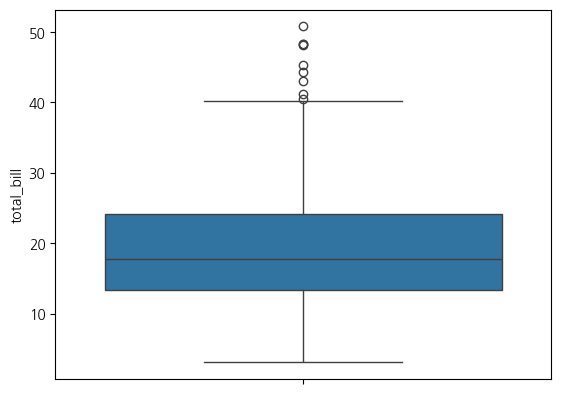

In [30]:
# 2. 박스플롯

#박스플롯(Boxplot)
#전체 분포 현황을 직관적으로 보여준다면,
#boxplot은 박스와 수염 모양으로 여러 가지 정보를 알려준다. (최솟값, 최댓값, Q1, Q2(중위수), Q3 값)
#형태는 sns.boxplot(x or y, data)
#데이터의 중심적인 분포를 파악하고, 이상치를 안정적으로 탐지

sns.boxplot(tips["total_bill"])


# ▶ 이상치 판단 기준 (통계적으로)
# 상한 (upper bound): Q3 + 1.5 × IQR # IQR=Q3−Q1  #데이터 집합에서 제3사분위수(Q3)와 제1사분위수(Q1) 간의 차이
# 하한 (lower bound): Q1 - 1.5 × IQR


# 요소    설명
# Q1 (제1사분위수)    하위 25% 지점의 값
# Q2 (중앙값 / Median)    50% 지점의 값, 상자의 중앙 선
# Q3 (제3사분위수)    상위 25% 지점의 값
# IQR (Interquartile Range)    Q3 - Q1
# 하한 (Lower Bound)    Q1 - 1.5 × IQR
# 상한 (Upper Bound)    Q3 + 1.5 × IQR
# 이상치 (Outliers)    상한을 넘거나 하한보다 작은 값 (점으로 표시됨)

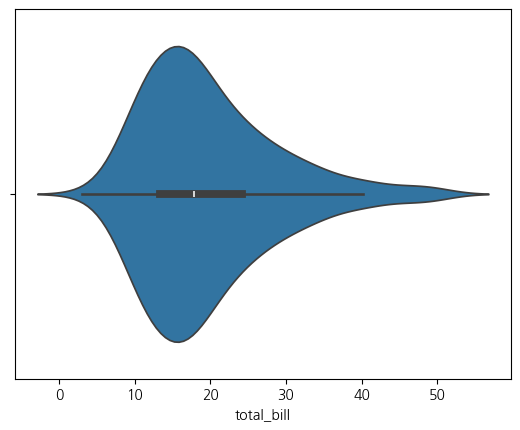

In [31]:
# 바이올린 플롯

# boxplot 분포는 확인 하기 좋음
# 분산이 어떤지 확인 하기 어려움


#분산을 확인 하기 위한게, 바이올린 그래프임
#sns.violinplot(x="time", y="total_bill",data=df_tips)

sns.violinplot(data=tips, x="total_bill")
plt.show()

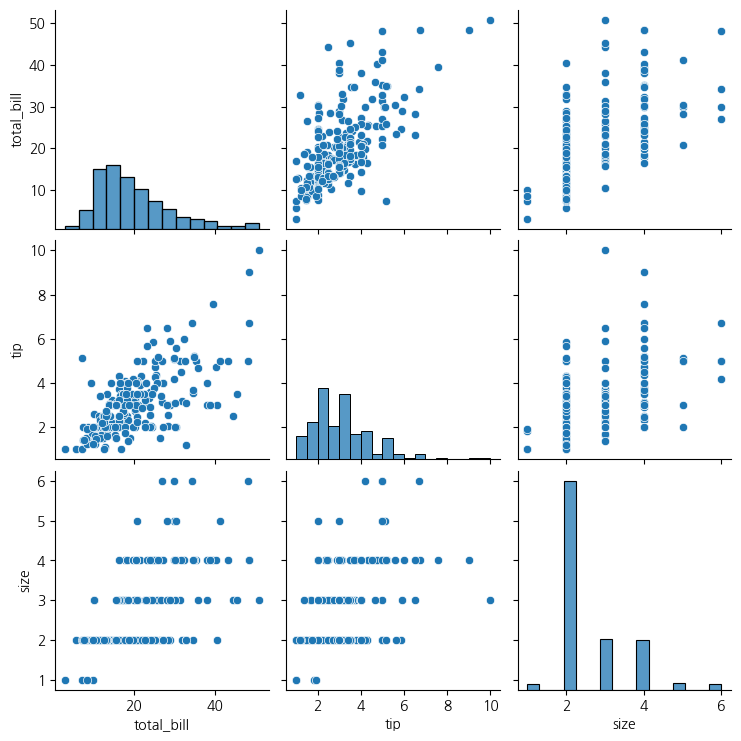

In [32]:
# 페어 플롯

# seaborn 간판 가장 강력한 기능

# 데이터 수치형 변수들의 쌍별 관계를 한눈데 보여주는 시각화 기능
# 자기가 알아서 이산형(size), 연속형(total_bill,tips) 구분해서 히스토그램 및 산점도 각각에 대응해서 그려줌
# 산점도와 히스토그램 그래프를  각 변수 간의 모든 가능한 조합을 2차원 그래프로 그려줌


sns.pairplot(df_tips)

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


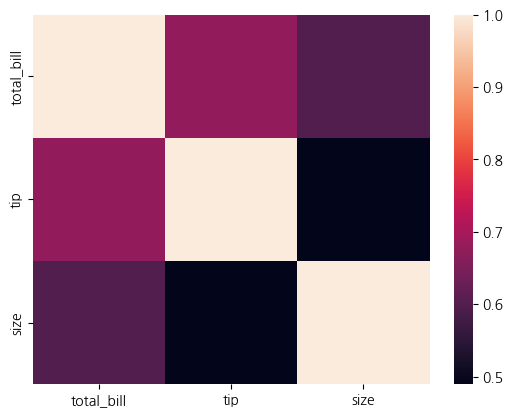

In [36]:
# 3. 수치형 변수 2개 이상 시각화(변수 간 관계 확인)

#히트맵: sns.heatmap()
#라인플롯: sns.lineplot()
#산점도: sns.scatterplot()
#회귀선 + 산점도: sns.regplot()

# 4. 히트맵(heatmap)
#보통 히트맵은 수치형 변수들 간의 상관관계를 나타낼 때 자주 사용한다.

#tips 데이터셋의 상관계수를 구해보자. corr() 함수를 사용한다.
#히트맵 예전버전과 에러
#https://twdatastory.tistory.com/entry/tipscorr-ValueError-could-not-convert-string-to-float-No

#피어슨 상관관계 설명
#https://dd0za-1004.tistory.com/46

#공분산의 이해
#https://ds92.tistory.com/124


tip_corr = tips.corr(numeric_only=True) # 피어슨 상관계수
print(tip_corr)

sns.heatmap(tip_corr)
plt.show()

# 분석
# 1. 팁과 전체 금액과는 상관관계가 있으며, size 와는 관계는 있으나 약해 보임
# 절댓값이 1에 가까운 상관계수: 매우 확고한 상관.

<Axes: xlabel='size', ylabel='tip'>

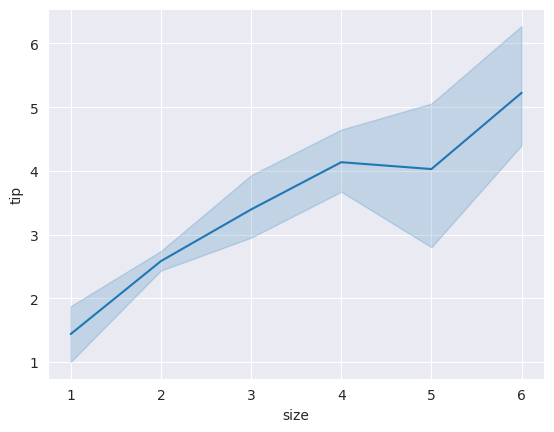

In [40]:
# 라인 플롯

#라인플롯은 두 수치형 데이터 사이의 관계를 선으로 나타낸다.
#주로 x축에는 이산형(discrete) 데이터, y축에는 연속형(continuous) 데이터를 쓸 때 사용한다.
#그 이유는 x값에 따른 y값의 평균값을 선으로 이어주기 때문이다.
#형태는 sns.lineplot(x, y, hue(범주형), data)

#스타일 설정
#style : 'white', 'dark', 'whitegrid', 'darkgrid' 
sns.set_style("darkgrid")

# 두 수치형 데이터 size, tip 간 관계를 시각화
sns.lineplot(x='size',y='tip',data=df_tips)

# 참고로 그림자가 넓다 = 데이터가 많이 흔들린다(분산 큼),
# 그림자가 좁다 = 데이터가 안정적이다(분산 작음) 라고 해석하는 경우가 많습니다.
# 라인은 기본적으로 평균임



# 분석
#1. 인원수가 증가 할수록 팁도 증가하는 경향이 있다
#2. 변동성이나 이상값도 해당 그래프에서 그림자로 확인 가능
#3. 그림자는 보통 신뢰구간 또는 오차범위

<Axes: xlabel='total_bill', ylabel='tip'>

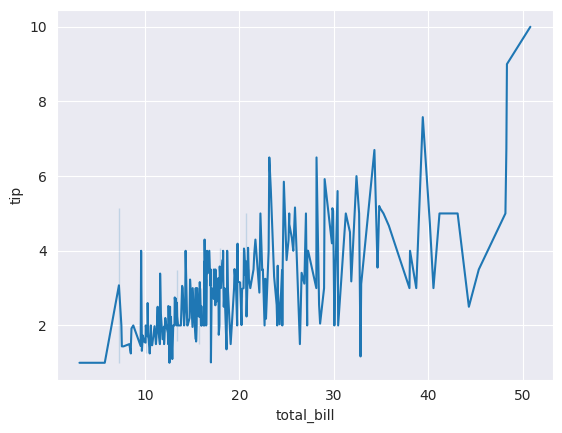

In [43]:

# x,y 둘다 연속형을 쓰면? 이상 해 짐
sns.lineplot(x='total_bill',y='tip',data=df_tips)

# 분석
# 라인플롯에서 연속형 데이터를 둘다 x,y 축으로 쓰면 안됨(이상해짐)

<Axes: xlabel='total_bill', ylabel='tip'>

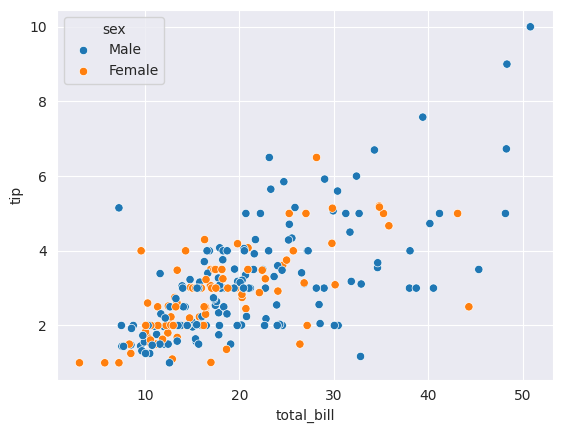

In [44]:
# 산점도 
# 주로 x, y축에 모두 연속형 데이터를 넣을 때 자주 사용한다.
# 형태는 sns.scatterplot(x, y, hue(범주형), data)

sns.scatterplot(x="total_bill",y="tip",data=df_tips,hue="sex")

# 분석
# 1. 총금액이 많아 질수록 팁도 많아 지는 경향이 있다.
# 2. 이상치도 그래프로 확인 가능하다

<Axes: xlabel='size', ylabel='tip'>

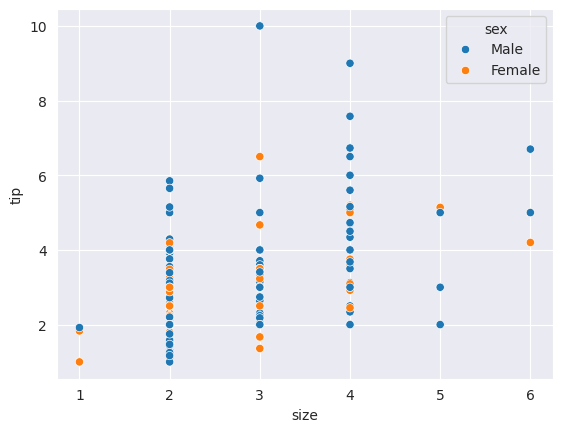

In [45]:
sns.scatterplot(x="size",y="tip",data=df_tips,hue="sex")

# 산점도에서 x축에 범주형 변수도 분석이 가능하다
# 사이즈 3의 10은 확실히 이상치로 보인다. (여기에서의 해석은 팁은 가끔 많이 받을때도 있다라고 해석)
# 식사인원이 많을 수록 평균적인 팁 금액이 증가하는 경향이 있으나,
# 5인 6인은 데이터 부족으로 인하여, 인원수가 커도 팁이 꼭 많지는 않다는 것을 확인 할수 있다.
# 범주형이 x축에 있으면, 이상치 확인이 용이하다.

<Axes: xlabel='day', ylabel='count'>

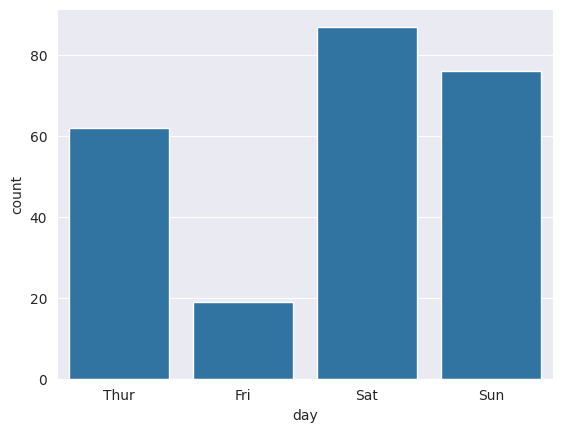

In [46]:
# 범주형 데이터
sns.countplot(x="day",data=df_tips)

#분석 
# 1. 범주형 데이터는 변수 1개 짜리는 countplot으로 분석 할수 있다. (plt.bar())
# 생각보다 금요일에 사람이 안온다 한국은 불금인데
# 주말에는 평일보다 손님이 많은것을 확인 할수 있다.


<Axes: xlabel='smoker', ylabel='count'>

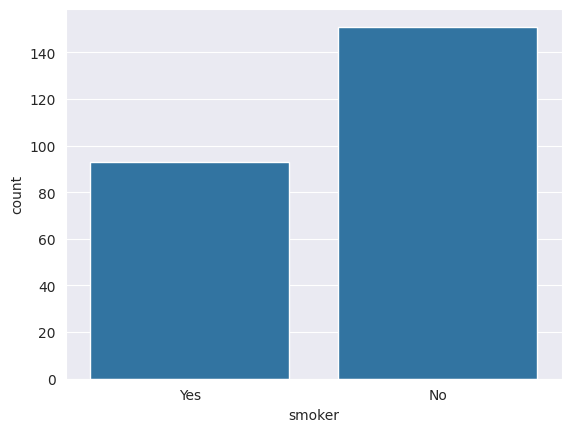

In [47]:
sns.countplot(x="smoker",data=df_tips)

# 분석
# 1. 비흡연자가 더 많이 방문했음을 알수 있다.


<Axes: xlabel='sex', ylabel='count'>

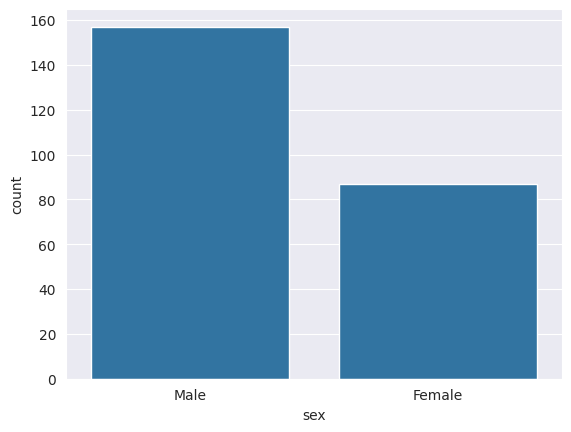

In [48]:
sns.countplot(x="sex",data=df_tips)
# 분석
# 남성이 여성보다 더 많이 방문 했음

<Axes: xlabel='time', ylabel='count'>

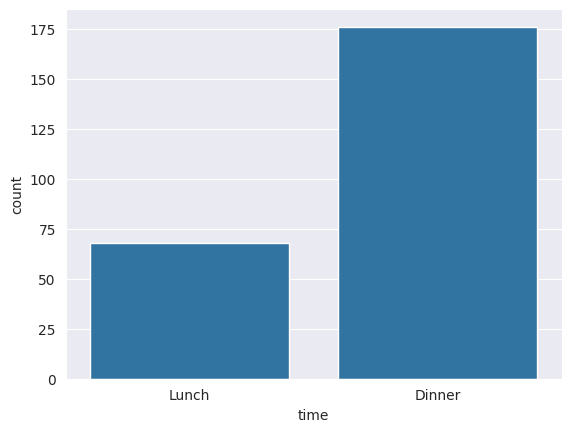

In [49]:
sns.countplot(x="time",data=df_tips)

# 분석
# 저녁때 점심보다 두배이상 방문 했음.

<Axes: xlabel='sex', ylabel='tip'>

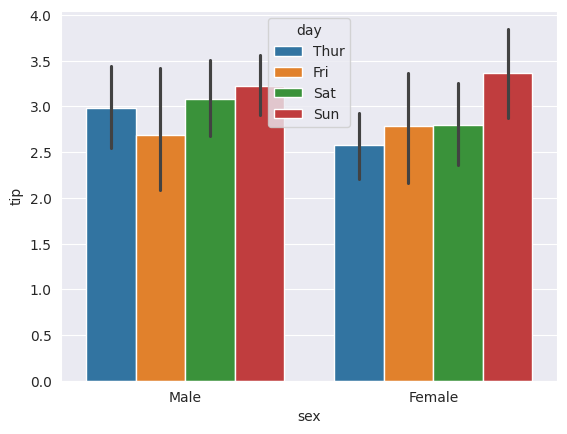

In [51]:
# 범주형 그래프 - x,y 처리 그래프

# 막대그래프

# 검은 세로선은 해당 평균의 95% 신뢰구간
# male의 팁 평균이 3.0이고, 검은선이 2.5~3.5라면:
# 실제 평균 팁이 이 범위 안에 있을 확률이 95%다 라는 통계적 의미

sns.barplot(x = "sex", y = "tip", data = df_tips, hue = "day")

<Axes: xlabel='day', ylabel='tip'>

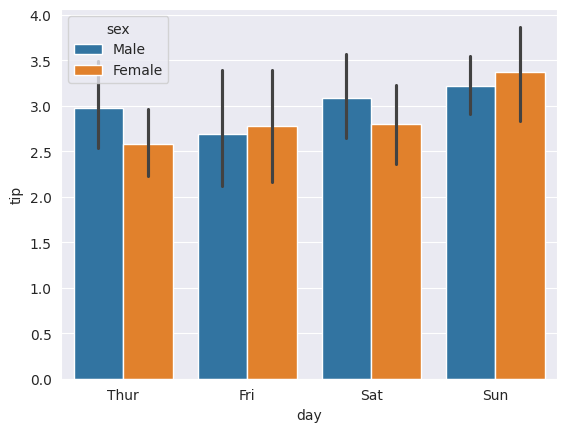

In [ ]:
sns.barplot(x = "day", y = "tip", data = df_tips, hue = "sex")

# 분석
# 주말일수록 팁을 더 내는 경향이 있다.
# 일요일에 남자든 여자든 성별 상관없이 팁을 가장 많이 내었다.


<Axes: xlabel='time', ylabel='total_bill'>

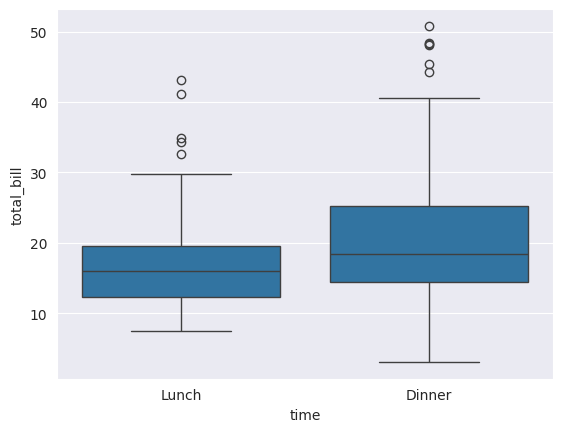

In [ ]:
# 박스 플롯
sns.boxplot(x="time", y="total_bill",data=df_tips)

# 분석
# 1. 저녁이 점심보다 더 많이 쓴다.
# 2. 점심은 상대적으로 변동성이 적고 , 중앙값도 낮다 > 점심은 간단히 저녁은 다양하고 고가로 먹는 경향이 있다.
# 3. 점심 데이터는 중위값 근처에 몰린 데이터가 많다.

# 결론
# 점심은 간단히 저녁은 다양하고 고가로

<Axes: xlabel='total_bill', ylabel='time'>

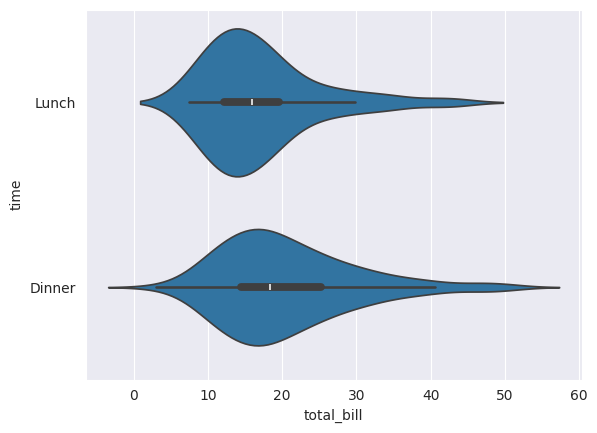

In [55]:
sns.violinplot(x="total_bill", y="time",data=df_tips)